# **Problem 2b)**

In [98]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [99]:
 # Direct upload through left file pick icon -- adds in /content automatically

img = cv2.imread('data/parrot.png', cv2.IMREAD_GRAYSCALE)

In [100]:
# Declare filter F
F = np.array([
    [ 1/9, 1/9, 1/9],
    [ 1/9, 1/9, 1/9],
    [ 1/9, 1/9, 1/9]
], dtype=float)

In [101]:
pad_h, pad_w = F.shape[0]//2, F.shape[1]//2
I_pad = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)

In [102]:
H, W = img.shape
G = np.zeros((H, W), dtype=float)
f_vec = F.flatten()

In [103]:
for i in range(H):
    for j in range(W):
        patch = I_pad[i : i+F.shape[0], j : j+F.shape[1]]
        t_vec = patch.flatten()
        G[i, j] = f_vec.dot(t_vec)

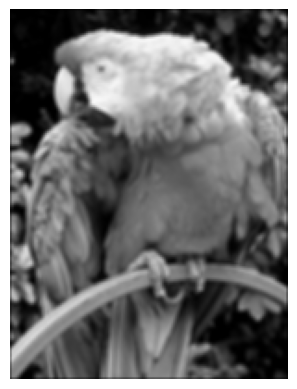

In [104]:
plt.imshow(G, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

# **Problem 3a)**

In [200]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [201]:
# Parameters
LINE_POINT_DIST_THRESHOLD = 0.2
MIN_POINTS_PER_SEGMENT = 5
MIN_SEG_LENGTH = 0.5
MAX_P2P_DIST = 0.3

In [203]:
# Direct upload through left file pick icon -- adds in /content automatically

rangeData1 = pd.read_excel('data/rangeData_4_9_360.xlsx', header=None).to_numpy()
rangeData2 = pd.read_excel('data/rangeData_5_5_180.xlsx', header=None).to_numpy()
rangeData3 = pd.read_excel('data/rangeData_7_2_90.xlsx', header=None).to_numpy()

In [204]:
# 1st line is robot's position(origin)

# Split and Merge Line Extraction

def split_and_merge(range_data, dist_thresh, min_points, min_seg_len, max_p2p):

    # Remove 1st line in angle
    theta = range_data[1:, 0]  # radians
    # Remove 1st line in relative position
    rho = range_data[1:, 1]

    x = rho * np.cos(theta)
    y = rho * np.sin(theta)
    points = np.column_stack((x, y))

    max_depth = 100  # Prevent infinite recursion

    def recursive_split(pts, depth):
        if len(pts) < min_points or depth > max_depth:
            return [pts]

        coeff = np.polyfit(pts[:, 0], pts[:, 1], 1)
        line_func = lambda x: coeff[0] * x + coeff[1]
        distances = np.abs(pts[:, 1] - line_func(pts[:, 0])) / np.sqrt(1 + coeff[0] ** 2)

        max_dist_idx = np.argmax(distances)
        max_dist = distances[max_dist_idx]

        if max_dist > dist_thresh and 0 < max_dist_idx < len(pts) - 1:
            print(f"Splitting at depth {depth}, maxDist = {max_dist:.4f}")
            left = recursive_split(pts[:max_dist_idx+1], depth + 1)
            right = recursive_split(pts[max_dist_idx:], depth + 1)
            return left + right
        else:
            return [pts]

    raw_segments = recursive_split(points, 0)

    lines = []
    for seg in raw_segments:
        if len(seg) >= min_points:
            seg_len = np.linalg.norm(seg[-1] - seg[0])
            if seg_len >= min_seg_len:
                lines.append(seg)

    return lines

In [206]:
# Plotting function
def plot_segments_side_by_side(all_lines, titles):
    fig, axs = plt.subplots(1, len(all_lines), figsize=(18, 6))

    for i, (segments, title) in enumerate(zip(all_lines, titles)):
        ax = axs[i]
        for seg in segments:
            seg = np.array(seg)
            ax.plot(seg[:, 0], seg[:, 1], '-o')
        ax.set_title(title)
        ax.set_xlabel('X (m)')
        ax.set_ylabel('Y (m)')
        ax.axis('equal')
        ax.grid(True)

    plt.tight_layout()
    plt.show()

Splitting at depth 0, maxDist = 4.7094
Splitting at depth 0, maxDist = 5.4565
Splitting at depth 1, maxDist = 1.7974
Splitting at depth 2, maxDist = 1.2067
Splitting at depth 0, maxDist = 6.8552
Splitting at depth 1, maxDist = 1.0491
Splitting at depth 2, maxDist = 0.8460


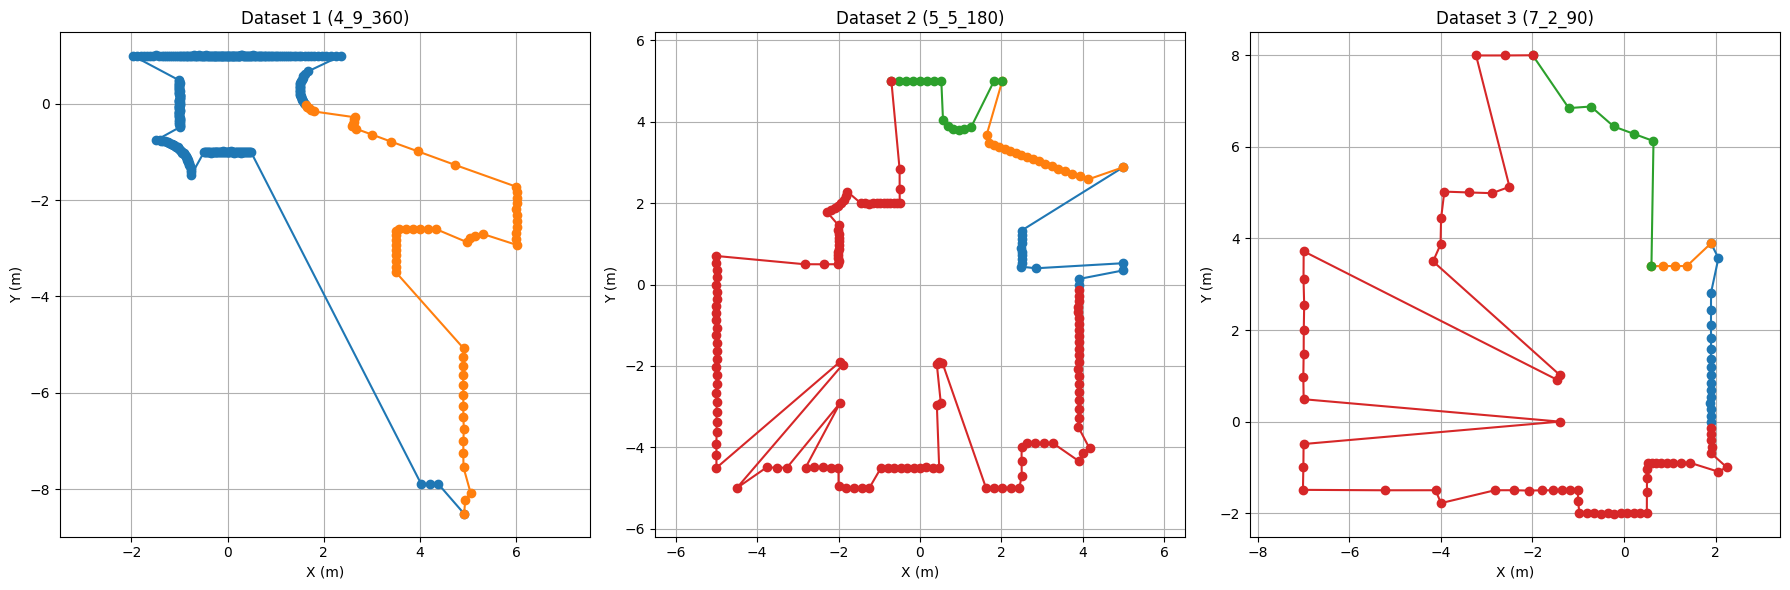

In [207]:
# Process
lines1 = split_and_merge(rangeData1, LINE_POINT_DIST_THRESHOLD, MIN_POINTS_PER_SEGMENT, MIN_SEG_LENGTH, MAX_P2P_DIST)
lines2 = split_and_merge(rangeData2, LINE_POINT_DIST_THRESHOLD, MIN_POINTS_PER_SEGMENT, MIN_SEG_LENGTH, MAX_P2P_DIST)
lines3 = split_and_merge(rangeData3, LINE_POINT_DIST_THRESHOLD, MIN_POINTS_PER_SEGMENT, MIN_SEG_LENGTH, MAX_P2P_DIST)

# Plot side by side
plot_segments_side_by_side(
    [lines1, lines2, lines3],
    ["Dataset 1 (4_9_360)", "Dataset 2 (5_5_180)", "Dataset 3 (7_2_90)"]
)
